# Proje Özeti: DNA Kodon Kullanımı ile Canlı Sınıflandırması

Bu proje, canlıların DNA kodon kullanım sıklıklarını (Codon Usage) analizerek hangi biyolojik krallığa (Kingdom) ait olduklarını **Gradient Boosting** algoritması kullanarak tahmin etmeyi amaçlar.

### 1. Veri Seti ve Ön Hazırlık
* **Veri Kaynağı:** `codon_usage.csv` dosyası kullanılmıştır (13.028 örnek, 69 özellik).
* **Veri Temizliği:**
    * `SpeciesID` ve `SpeciesName` gibi model başarısını etkilemeyecek tanımlayıcı sütunlar çıkarılmıştır.
    * `UUU` ve `UUC` sütunlarındaki sayısal olmayan veri tipi hataları giderilmiş ve float formatına dönüştürülmüştür.
* **Ön İşleme:**
    * Hedef değişken olan `Kingdom` (Krallık) sınıfı **LabelEncoder** ile sayısal değerlere dönüştürülmüştür.
    * Bağımsız değişkenler (kodon frekansları) **StandardScaler** kullanılarak ölçeklendirilmiş, böylece modelin daha hızlı ve doğru yakınsaması sağlanmıştır.

### 2. Modelleme Süreci
* **Algoritma:** Topluluk öğrenmesi (Ensemble Learning) yöntemlerinden **Gradient Boosting Classifier** seçilmiştir.
* **Eğitim:** Veri seti %80 eğitim ve %20 test olacak şekilde ayrılmış (`random_state=42`), model bu veri üzerinde eğitilmiştir.
* **Optimizasyon:** Modelin performansını artırmak için **GridSearchCV** kullanılarak `learning_rate`, `n_estimators` ve `max_depth` gibi hiperparametreler optimize edilmiştir.

### 3. Değerlendirme ve Sonuçlar
* **Metrikler:** Modelin başarısı **Doğruluk (Accuracy)** skoru, **Karmaşıklık Matrisi (Confusion Matrix)** ve **Sınıflandırma Raporu (Classification Report)** ile detaylıca incelenmiştir.
* **Özellik Önemi:** Modelin karar verirken en çok hangi kodonlara (örneğin *CGC, CGA, vb.*) dikkat ettiğini gösteren "Feature Importance" analizi yapılmış ve en önemli 20 özellik görselleştirilmiştir.




In [3]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd  # Veri manipülasyonu (DataFrame) için
import numpy as np   # Sayısal işlemler ve matrisler için
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # Gelişmiş görselleştirme kütüphanesi
from sklearn.model_selection import train_test_split # Veriyi eğitim/test olarak ayırmak için
from sklearn.preprocessing import LabelEncoder, StandardScaler # Etiket kodlama ve Ölçeklendirme
from IPython.display import display

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Görselleştirme ayarı
sns.set_style("whitegrid") # Grafiklerin arka planını ızgaralı beyaz yapar

Veri Seti Boyutu: (13028, 69)


C:\Users\user\AppData\Local\Temp\ipykernel_4084\2165066296.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis') # 'Kingdom' sütununun değer sayım grafiğini çiz


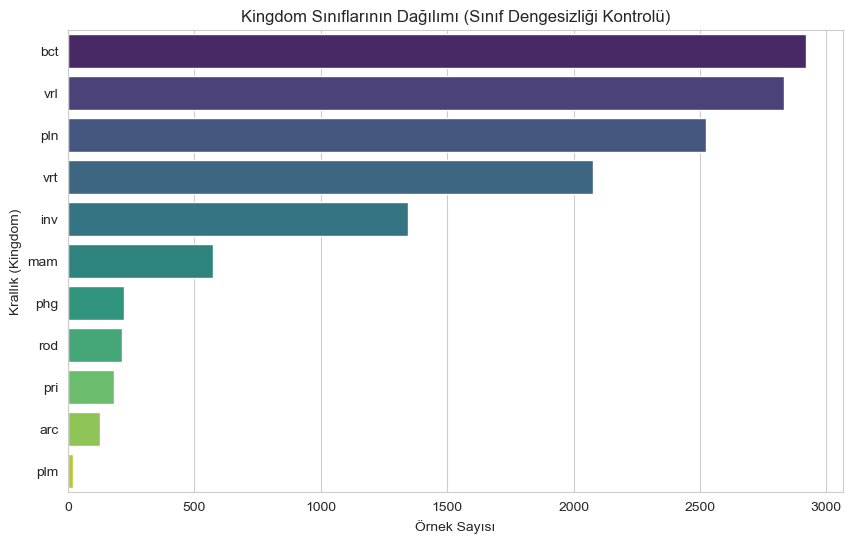

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA;
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0;
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0;
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144;
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0;
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131;


In [4]:
## Veri seti dosyadan (codon_usage.csv) yükleniyor.
# Ardından veri setinin boyutu (satır, sütun) yazdırılıyor ve 'Kingdom' (Krallık) sınıf dağılımı görselleştiriliyor (Sınıf dengesizliği kontrolü). 

df = pd.read_csv(r"C:\\Users\\user\\Documents\\2025-2026 Ders Notları\\Veri Madenciliği\\Güz Dönemi\\FET445_22040301045_BAC-Ganom_2\\data\\codon_usage.csv", low_memory=False)

print("Veri Seti Boyutu:", df.shape) # Yüklenen veri setinin boyutunu göster

plt.figure(figsize=(10, 6)) # Yeni bir çizim figürü oluştur
sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis') # 'Kingdom' sütununun değer sayım grafiğini çiz
plt.title('Kingdom Sınıflarının Dağılımı (Sınıf Dengesizliği Kontrolü)') # Başlık
plt.xlabel('Örnek Sayısı') # X ekseni etiketi
plt.ylabel('Krallık (Kingdom)') # Y ekseni etiketi
plt.show() 

display(df.head()) # Veri setinin ilk 5 satırını göster

In [5]:
# Özellik tanımlamaları yapılıyor. Kodon (UUU, UUC, vb.), 'Ncodons' ve 'DNAtype' sütunları sayısal özellikler olarak belirleniyor.
# Ardından, sayısal olması gereken sütunlarda ondalık ayracı olarak kullanılan virgüller (,) noktaya (.) çevriliyor ve sütunlar sayısal tipe zorlanıyor.
# Son olarak, modelleme için gereksiz olan 'SpeciesID' ve 'SpeciesName' sütunları veri setinden çıkarılıyor.

codon_cols = df.columns[5:] # Kodon frekans sütunlarını seç
other_numeric_cols = ['Ncodons', 'DNAtype'] # Diğer sayısal sütunlar
numeric_features = list(codon_cols) + other_numeric_cols # Tüm sayısal özellik listesi

print("--- 3. Temizlik Başlangıç (Virgül -> Nokta) ---") 
for col in numeric_features: # Sayısal olması gereken her sütun için döngü
    if df[col].dtype == 'object': # Sütun tipi 'object' (string) ise
       
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False), # Virgülleri noktaya çevir
            errors="coerce" # Dönüşüm hatası olursa NaN yap
        )

df_cleaned = df.drop(columns=['SpeciesID', 'SpeciesName']).copy() # Gereksiz sütunları sil ve kopyala

--- 3. Temizlik Başlangıç (Virgül -> Nokta) ---


C:\Users\user\AppData\Local\Temp\ipykernel_4084\2851981953.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Kingdom', data=df, palette='viridis', order=df['Kingdom'].value_counts().index)


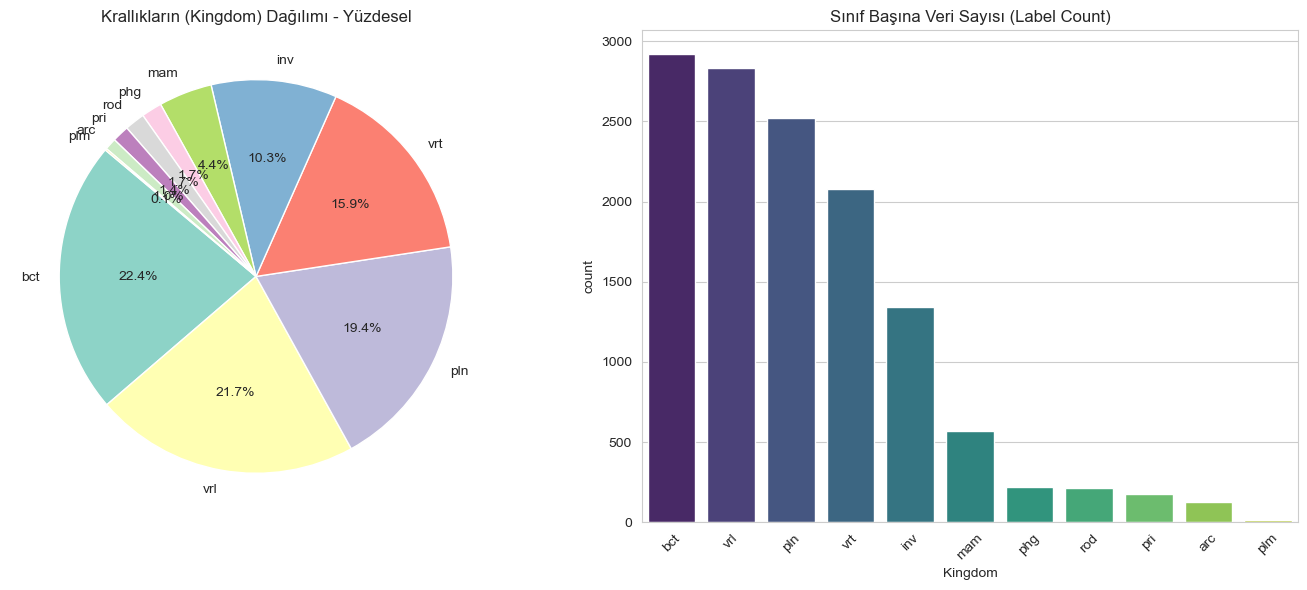

Analiz Edilen Toplam Örnek Sayısı: 13028


In [6]:
# Bu kod bloğu, veri setini yeniden yüklemeden, hafızadaki mevcut veri çerçevesi (df) 
# üzerinde çalışır. Amaç, hedef değişken olan 'Kingdom' (Krallık) sınıflarının 
# dağılımını hem oransal (Pasta Grafiği) hem de sayısal (Sütun Grafiği) olarak 
# görselleştirerek veri dengesini analiz etmektir.


import seaborn as sns

plt.figure(figsize=(14, 6))

# 1. Pasta Grafiği (Pie Chart) - Krallıkların Yüzdesel Dağılımı
plt.subplot(1, 2, 1)
df['Kingdom'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Krallıkların (Kingdom) Dağılımı - Yüzdesel')
plt.ylabel('') # Gereksiz etiketi kaldırır

# 2. Sütun Grafiği (Histogram/Count Plot) - Sınıf Sayıları
plt.subplot(1, 2, 2)
sns.countplot(x='Kingdom', data=df, palette='viridis', order=df['Kingdom'].value_counts().index)
plt.title('Sınıf Başına Veri Sayısı (Label Count)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Veri boyutunu yazdırılıyor.
print(f"Analiz Edilen Toplam Örnek Sayısı: {df.shape[0]}")

In [7]:
# Biyolojik bir özellik olan GC Oranı (Guanin ve Sitozin içeriği) hesaplanarak yeni bir öznitelik (GC_Content) türetiliyor.
# Bu, her bir türün kodon frekansları kullanılarak GC oranının yaklaşık bir tahmini olarak hesaplanır.

def calculate_gc_content(row): # GC içeriği hesaplama fonksiyonu
    gc_score = 0 # GC skoru sıfırla
    for codon in codon_cols: # Her bir kodon için döngü
        gc_count = codon.count('G') + codon.count('C') # Kodondaki G ve C sayısını bul
        gc_score += row[codon] * gc_count # Frekans * G/C sayısını topla
        
    return gc_score / 3 # Skoru 3'e bölerek normalize et

print("Yeni özellik 'GC_Content' hesaplanıyor... (Biraz sürebilir)") # Hesaplama mesajı
df_cleaned['GC_Content'] = df_cleaned.apply(calculate_gc_content, axis=1) # Fonksiyonu her satıra uygula

print("İşlem Tamam! Yeni veri setinin boyutu:", df_cleaned.shape) # Yeni boyutu göster
print("Örnek GC Oranları:") # Örnek GC oranları mesajı
print(df_cleaned[['GC_Content']].head()) # İlk 5 GC_Content değerini göster

Yeni özellik 'GC_Content' hesaplanıyor... (Biraz sürebilir)
İşlem Tamam! Yeni veri setinin boyutu: (13028, 68)
Örnek GC Oranları:
   GC_Content
0         NaN
1         NaN
2         NaN
3         NaN
4         NaN


In [8]:
# Veri seti, 'Kingdom' hedef değişkenine göre katmanlı (stratified) bir şekilde %80 eğitim (train) ve %20 test (test) olarak ikiye ayrılıyor.
# Bu ayrım, her bir krallık sınıfının oranının hem eğitim hem de test setinde korunmasını sağlar.

X = df_cleaned.drop(columns=['Kingdom']) # Özellikler (kodon frekansları, vb.)
y = df_cleaned['Kingdom'] # Hedef değişken (Krallık)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # Stratify=y ile sınıf oranlarını koru
)

train_df = pd.concat([X_train, y_train], axis=1) # Eğitim setini birleştir
test_df = pd.concat([X_test, y_test], axis=1) # Test setini birleştir

print("\n--- Veri Ayırma Sonuçları ---") 
print(f"X_train Boyutu: {X_train.shape}") # Eğitim özellik seti boyutunu yazdır
print(f"X_test Boyutu: {X_test.shape}") # Test özellik seti boyutunu yazdır


--- Veri Ayırma Sonuçları ---
X_train Boyutu: (10422, 67)
X_test Boyutu: (2606, 67)


In [9]:
# KONTAMİNASYONU ENGELLEYEN İŞLEM SIRASI:
# 1. Eksik Değer Doldurma (Imputation): Test setindeki eksik değerler bile, sadece eğitim setinin ortalaması kullanılarak doldurulur.
# 2. Kategorik Hedef Değişken Kodlama (Encoding): 'Kingdom' etiketleri (arc, bct, vb.) sayısal değerlere dönüştürülür.
# 3. Özellik Ölçeklendirme (Scaling): Sayısal özellikler, eğitim setine göre standartlaştırılarak (StandardScaler) makine öğrenimi modeline hazır hale getirilir.

train_means = train_df[numeric_features].mean() # Eğitim setindeki ortalamaları hesapla

train_df[numeric_features] = train_df[numeric_features].fillna(train_means) # Eğitim setini doldur
test_df[numeric_features] = test_df[numeric_features].fillna(train_means) # Test setini doldur

print("\nEksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).") 

le = LabelEncoder() # LabelEncoder nesnesi oluştur
train_df['Kingdom_Encoded'] = le.fit_transform(train_df['Kingdom']) # Eğitim etiketlerini kodla (fit ve transform)
test_df['Kingdom_Encoded'] = le.transform(test_df['Kingdom']) # Test etiketlerini kodla (sadece transform)

print("Krallık Kodlaması:", dict(zip(le.classes_, le.transform(le.classes_)))) # Kodlama haritasını göster

scaler = StandardScaler() # StandardScaler nesnesi oluştur

scaler.fit(train_df[numeric_features]) # Ölçekleyiciyi eğitim setine fit et

train_df[numeric_features] = scaler.transform(train_df[numeric_features]) # Eğitim setini dönüştür
test_df[numeric_features] = scaler.transform(test_df[numeric_features]) # Test setini dönüştür

print("Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).") 


Eksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).
Krallık Kodlaması: {'arc': np.int64(0), 'bct': np.int64(1), 'inv': np.int64(2), 'mam': np.int64(3), 'phg': np.int64(4), 'plm': np.int64(5), 'pln': np.int64(6), 'pri': np.int64(7), 'rod': np.int64(8), 'vrl': np.int64(9), 'vrt': np.int64(10)}
Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).


In [10]:
# Tüm ön işleme adımları (imputation, encoding, scaling) tamamlandıktan sonra, makine öğrenimi modellerini eğitmek ve test etmek için kullanılacak nihai X_train, y_train, X_test ve y_test veri setleri oluşturuluyor.
# Bu nihai setler, gelecekteki modelleme çalışmalarını kolaylaştırmak için CSV dosyaları olarak kaydediliyor.


X_train_final = train_df.drop(columns=['Kingdom', 'Kingdom_Encoded']) # Eğitim özellikleri
y_train_final = train_df['Kingdom_Encoded'] # Eğitim etiketleri (kodlanmış)
X_test_final = test_df.drop(columns=['Kingdom', 'Kingdom_Encoded']) # Test özellikleri
y_test_final = test_df['Kingdom_Encoded'] # Test etiketleri (kodlanmış)

X_train_final.to_csv('X_train_final_KUSURSUZ.csv', index=False) # X_train'i kaydet
X_test_final.to_csv('X_test_final_KUSURSUZ.csv', index=False) # X_test'i kaydet
pd.DataFrame({'Kingdom_Encoded': y_train_final.values, 'Kingdom_Original': train_df['Kingdom'].values}).to_csv('y_train_encoded_final_KUSURSUZ.csv', index=False) # y_train'i kaydet
pd.DataFrame({'Kingdom_Encoded': y_test_final.values, 'Kingdom_Original': test_df['Kingdom'].values}).to_csv('y_test_encoded_final_KUSURSUZ.csv', index=False) # y_test'i kaydet

print("\n--- TEBRİKLER! ---")
print("Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir. ✅") 




--- TEBRİKLER! ---
Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir. ✅


Güvenlik temizliği yapıldı. NaN kontrolü:  0

--- SEÇİLEN EN İYİ 20 KODON ---
['DNAtype', 'UUC', 'UUG', 'CUC', 'CUA', 'AUC', 'GCG', 'CCA', 'CCG', 'UGG', 'ACC', 'ACA', 'ACG', 'UGU', 'AAG', 'CGU', 'CGC', 'AGA', 'AGG', 'GAU']


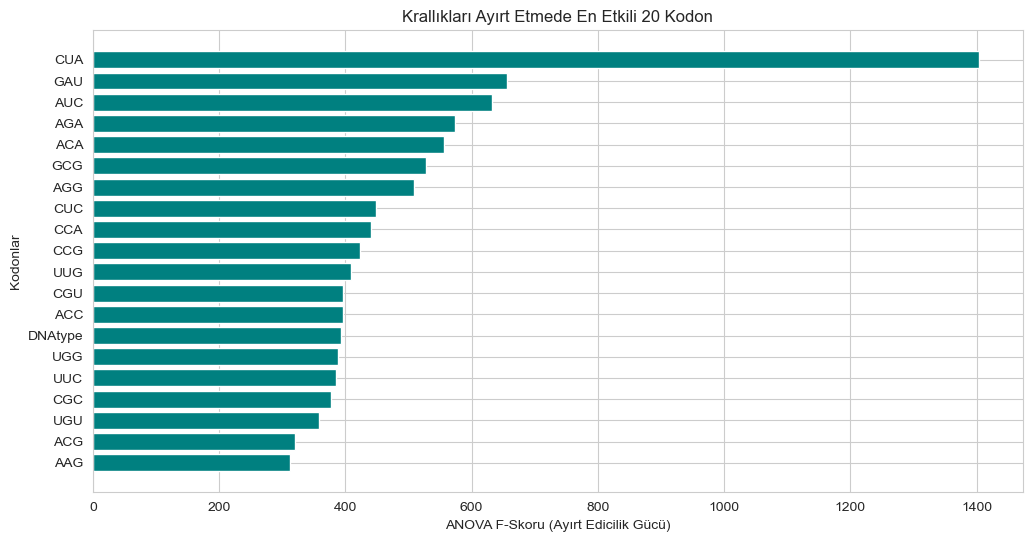

In [11]:
## ANOVA F-Skoru (f_classif) kullanılarak hedef değişkeni (Krallık) en iyi ayırt eden 20 öznitelik (kodon/özellik) seçiliyor (SelectKBest).
# Öznitelik seçimi, modelin gereksiz gürültüden arındırılması ve eğitim süresinin azaltılması için bir boyut indirgeme yöntemidir.

from sklearn.feature_selection import SelectKBest, f_classif # Öznitelik seçimi için kütüphaneler
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean') # Eksik değerleri ortalama ile dolduracak nesne

X_train_final = pd.DataFrame(imputer.fit_transform(X_train_final), columns=X_train_final.columns) # Eğitim setini doldur ve DataFrame yap
X_test_final = pd.DataFrame(imputer.transform(X_test_final), columns=X_test_final.columns) # Test setini doldur ve DataFrame yap

print("Güvenlik temizliği yapıldı. NaN kontrolü: ", X_train_final.isnull().sum().sum()) # NaN kontrolü


k_best_selector = SelectKBest(score_func=f_classif, k=20) # En iyi 20 özelliği seçecek nesne
X_train_selected = k_best_selector.fit_transform(X_train_final, y_train_final) # Eğitim setini fit et/dönüştür
X_test_selected = k_best_selector.transform(X_test_final) # Test setini dönüştür

selected_indices = k_best_selector.get_support(indices=True) # Seçilen özelliklerin indekslerini al
selected_features = X_train_final.columns[selected_indices] # Seçilen özellik isimlerini al

print(f"\n--- SEÇİLEN EN İYİ 20 KODON ---")
print(selected_features.tolist()) # Seçilen özellik listesini yazdır

scores = k_best_selector.scores_ # F-skorlarını al
feature_scores = pd.DataFrame({'Feature': X_train_final.columns, 'Score': scores}) # Skorları DataFrame'e dönüştür
feature_scores = feature_scores.sort_values(by='Score', ascending=False).head(20) # En yüksek 20 skoru al

plt.figure(figsize=(12, 6)) # Yeni çizim figürü
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='teal') # Yatay çubuk grafik çiz
plt.xlabel('ANOVA F-Skoru (Ayırt Edicilik Gücü)') # X ekseni etiketi
plt.ylabel('Kodonlar') 
plt.title('Krallıkları Ayırt Etmede En Etkili 20 Kodon') 
plt.gca().invert_yaxis() # Y eksenini ters çevir
plt.show() 

--- PCA SONUÇLARI ---
Orijinal Özellik Sayısı: 67
PCA Sonrası Bileşen Sayısı: 43
Korunan Toplam Varyans Oranı: %95.01


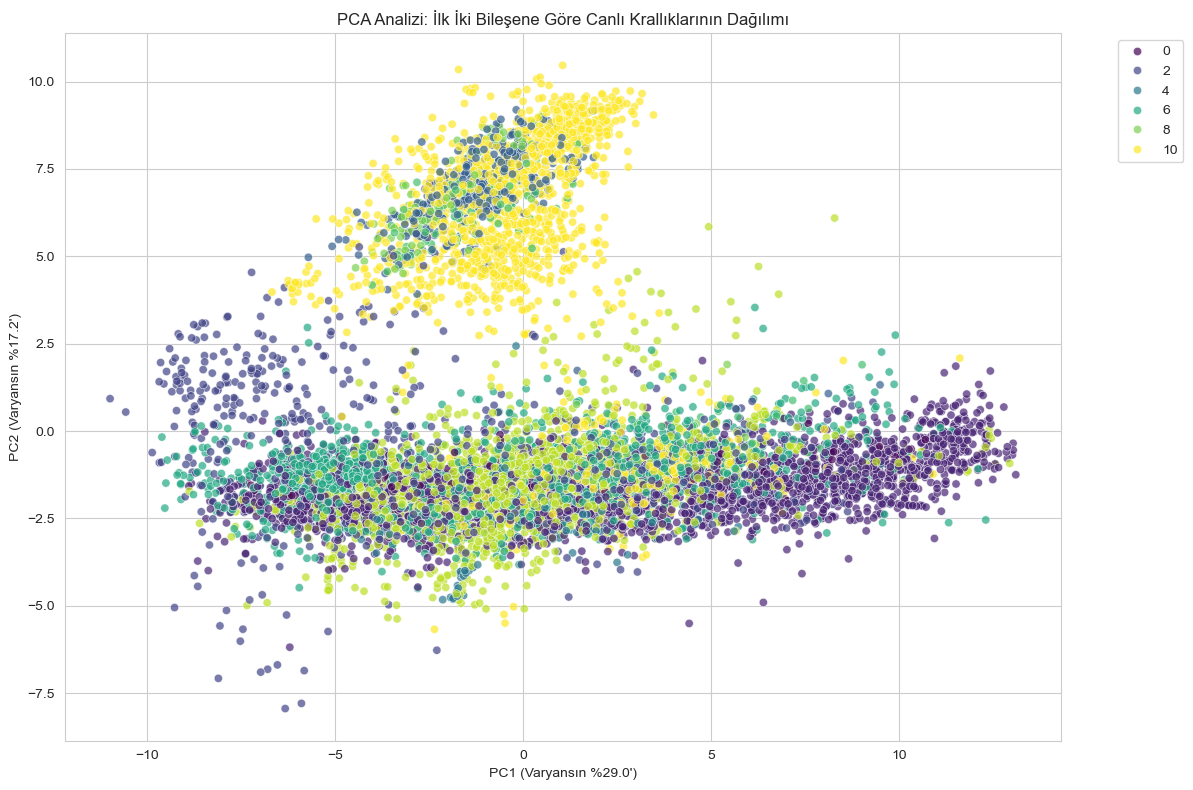

Orijinal özellik sayısı: 20
PCA sonrası bileşen sayısı: 15


In [12]:
## Temel Bileşen Analizi (PCA) kullanılarak veri setindeki varyansın (bilginin) %95'ini koruyacak kadar bileşen sayısı (43) belirleniyor ve veri bu yeni boyutlu uzaya indirgeniyor.
# Ayrıca ilk iki Temel Bileşen (PC1 ve PC2) kullanılarak krallıkların 2 boyutlu uzayda nasıl kümelendiği görselleştiriliyor.

from sklearn.decomposition import PCA # PCA kütüphanesi

pca = PCA(n_components=0.95) # %95 varyansı koruyacak PCA nesnesi
X_train_pca = pca.fit_transform(X_train_final) # Eğitim setini fit et/dönüştür
X_test_pca = pca.transform(X_test_final) # Test setini dönüştür

print(f"--- PCA SONUÇLARI ---") 
print(f"Orijinal Özellik Sayısı: {X_train_final.shape[1]}") 
print(f"PCA Sonrası Bileşen Sayısı: {X_train_pca.shape[1]}") 
print(f"Korunan Toplam Varyans Oranı: %{pca.explained_variance_ratio_.sum() * 100:.2f}") # Korunan varyans oranı

plt.figure(figsize=(12, 8)) # Yeni çizim figürü

pca_df = pd.DataFrame(data=X_train_pca[:, :2], columns=['PC1', 'PC2']) # İlk 2 PC ile DataFrame oluştur
pca_df['Kingdom'] = y_train_final.values

sns.scatterplot(x='PC1', y='PC2', hue='Kingdom', data=pca_df, palette='viridis', alpha=0.7) # Dağılım grafiği çiz
plt.title('PCA Analizi: İlk İki Bileşene Göre Canlı Krallıklarının Dağılımı') 
plt.xlabel(f'PC1 (Varyansın %{pca.explained_variance_ratio_[0]*100:.1f}\')') # PC1 eksen etiketi
plt.ylabel(f'PC2 (Varyansın %{pca.explained_variance_ratio_[1]*100:.1f}\')') # PC2 eksen etiketi
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout() 
plt.show() 

# PCA'yı eğitim verisine uydur ve dönüştür
X_train_pca = pca.fit_transform(X_train_selected)

# Test verisini aynı PCA ile dönüştür (fit yapmıyoruz!)
X_test_pca = pca.transform(X_test_selected)

print(f"Orijinal özellik sayısı: {X_train_selected.shape[1]}")
print(f"PCA sonrası bileşen sayısı: {X_train_pca.shape[1]}")

In [13]:
# Gradient Boosting algoritması için en iyi ayarları (hiperparametreleri) bulmayı sağlar.
# Veri dengesini koruyan Stratified K-Fold yöntemini kullanarak farklı kombinasyonları dener
# ve en başarılı modeli seçer.

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

# MODEL VE HİPERPARAMETRE AYARLARI ---

# Temel Gradient Boosting modelini tanımlıyoruz
gbc = GradientBoostingClassifier(random_state=42)

# Veriyi bölerken sınıf oranlarını koruyan çapraz doğrulama yapısı (Stratified K-Fold)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Optimize edilecek hiperparametre seti
param_grid = {
    'n_estimators': [50, 100],      # Kurulacak ağaç sayısı
    'learning_rate': [0.1, 0.2],    # Modelin öğrenme hızı
    'max_depth': [3]                # Her bir ağacın derinliği
}

# GRID SEARCH İLE EN İYİ PARAMETREYİ BULMA ---
print("Model eğitimi başlıyor, lütfen bekleyiniz...")
start_time = time.time()

# GridSearch, parametreleri kombinasyonlar halinde dener
grid_search = GridSearchCV(estimator=gbc,
                           param_grid=param_grid,
                           cv=cv_strategy,      # Belirlediğimiz K-Fold stratejisini uygular
                           scoring='accuracy',  # Başarı kriteri (Doğruluk)
                           n_jobs=-1,           # Hızlanmak için tüm işlemcileri kullanır
                           verbose=1)

# Modeli PCA uygulanmış verilerle eğitir
grid_search.fit(X_train_pca, y_train)

end_time = time.time()
print(f"Eğitim tamamlandı! Geçen süre: {round(end_time - start_time, 2)} saniye")
print(f"Bulunan En İyi Parametreler: {grid_search.best_params_}")

# En yüksek başarıyı veren modeli seçip atar
best_gbc_model = grid_search.best_estimator_

Model eğitimi başlıyor, lütfen bekleyiniz...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Eğitim tamamlandı! Geçen süre: 283.87 saniye
Bulunan En İyi Parametreler: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


In [14]:
#Bu kod bloğu, eğitilen modelin hiç görmediği test verisi üzerindeki performansını ölçer. 
# Doğruluk (Accuracy), F1 Skoru ve ROC AUC gibi metrikleri hesaplayarak sonuçları hem genel bir özet tablo 
# hem de sınıf bazlı detaylı bir rapor halinde sunar.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize


# TEST VERİSİ İLE TAHMİN VE RAPORLAMA ---

# 1. Eğitilmiş en iyi model ile tahmin yapıyoruz
print("Tahminler yapılıyor...")
y_pred = best_gbc_model.predict(X_test_pca)       # Test verisi üzerinde sınıf tahmini yapar
y_prob = best_gbc_model.predict_proba(X_test_pca) # ROC-AUC hesabı için tahmin olasılıklarını alır

# 2. Genel Performans Metriklerini Hesaplıyoruz
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted') # Dengesiz veri ihtimaline karşı ağırlıklı ortalama
auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted') # Çok sınıflı ROC-AUC skoru

# 3. Genel Karşılaştırma Tablosu (Final Raporu İçin)
genel_tablo = pd.DataFrame({
    'Model': ['Gradient Boosting'],
    'Best Params': [str(grid_search.best_params_)],
    'Accuracy': [acc],
    'F1 Score (Weighted)': [f1],
    'ROC AUC': [auc_score]
})

print("\n=== TABLO 1: GENEL MODEL PERFORMANSI ===")
print(genel_tablo)

# 4. Sınıf Bazlı Kırılım Tablosu
print("\n=== TABLO 2: SINIF BAZLI DETAYLI RAPOR (Classification Report) ===")
print(classification_report(y_test, y_pred)) # Her sınıf için Precision, Recall ve F1 detaylarını gösterir

Tahminler yapılıyor...

=== TABLO 1: GENEL MODEL PERFORMANSI ===
               Model                                        Best Params  \
0  Gradient Boosting  {'learning_rate': 0.2, 'max_depth': 3, 'n_esti...   

   Accuracy  F1 Score (Weighted)   ROC AUC  
0  0.816193             0.808634  0.971674  

=== TABLO 2: SINIF BAZLI DETAYLI RAPOR (Classification Report) ===
              precision    recall  f1-score   support

         arc       0.43      0.24      0.31        25
         bct       0.88      0.93      0.91       584
         inv       0.67      0.56      0.61       269
         mam       0.73      0.66      0.69       114
         phg       0.83      0.55      0.66        44
         plm       0.33      0.25      0.29         4
         pln       0.82      0.82      0.82       505
         pri       0.35      0.19      0.25        36
         rod       0.70      0.44      0.54        43
         vrl       0.83      0.91      0.87       567
         vrt       0.84      0.

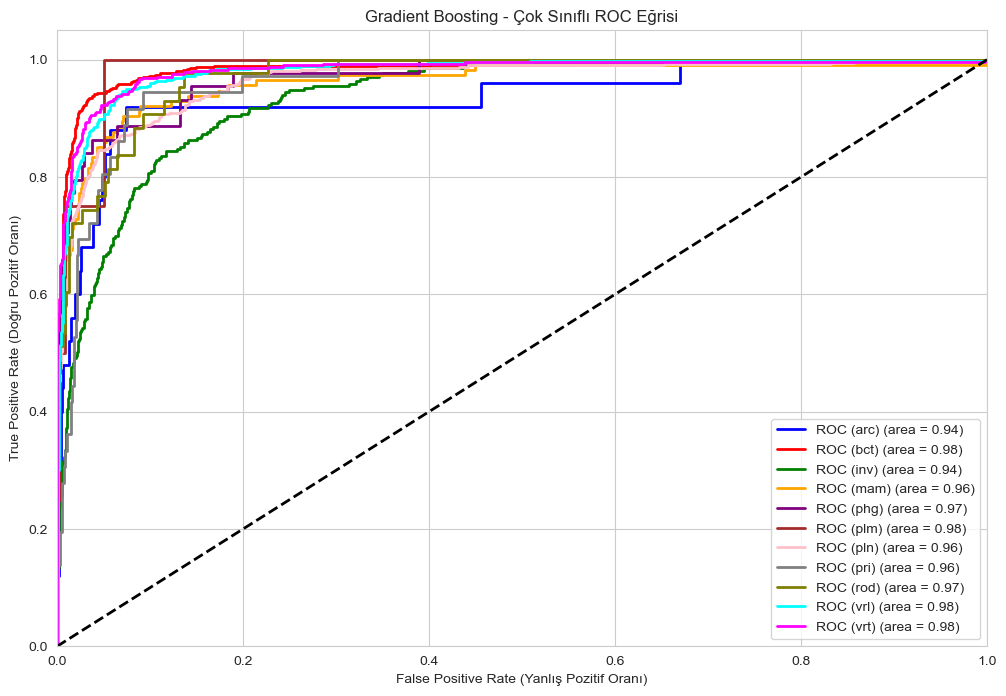

In [15]:

from sklearn.metrics import roc_curve, auc
from itertools import cycle

# ÇOK SINIFLI ROC EĞRİSİ ÇİZİMİ ---

# Hedef sınıfları (y_test) grafik için 0-1 formatına (binarize) çeviriyoruz
classes = best_gbc_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Her sınıf için FPR, TPR ve AUC hesaplıyoruz
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Çizim işlemi
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC ({0}) (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Gradient Boosting - Çok Sınıflı ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()

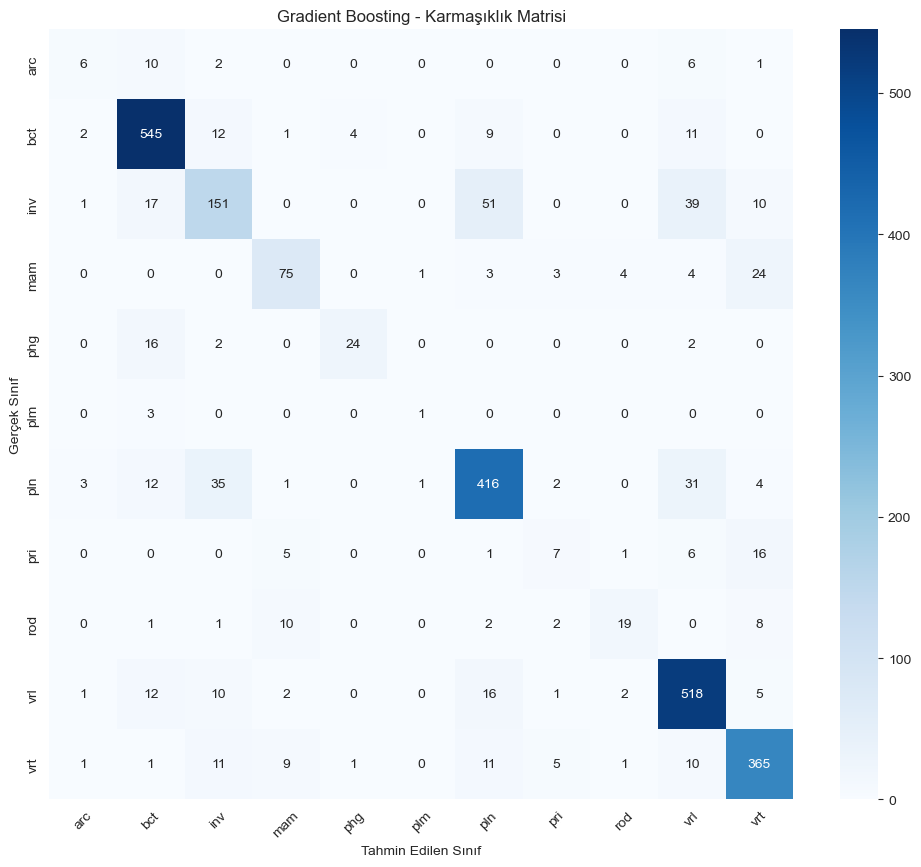

In [16]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

# KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) ---

# 1. Matrisi hesaplıyoruz
cm = confusion_matrix(y_test, y_pred)

# 2. Görselleştirme (Heatmap)
plt.figure(figsize=(12, 10)) # Boyutu biraz büyük tuttum ki sayılar net okunsun
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_gbc_model.classes_, 
            yticklabels=best_gbc_model.classes_)

plt.title('Gradient Boosting - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45) # Eksen yazılarını eğik yap ki sığsın
plt.show()